In [1]:
from arcgis import GIS

gis = GIS()
item = gis.content.get("8444e275037549c1acab02d2626daaee")
flayer = item.layers[0]
df = flayer.query().sdf
opacity_expression = ("var republican = $feature.MP06025a_B;var democrat = $feature.MP06024a_B;"
                      "var independent = $feature.MP06026a_B;var parties = [republican, democrat, independent];"
                      "var total = Sum(parties);var max = Max(parties);return (max / total) * 100;")
opacity_stops = [
    { "value": 33, "transparency": 0.05 * 255, "label": "< 33%" },
    { "value": 44, "transparency": 1.0 * 255, "label": "> 44%" }]
arcade_expression = ("var republican = $feature.MP06025a_B;var democrat = $feature.MP06024a_B;"
                     "var independent = $feature.MP06026a_B;var parties = [republican, democrat, independent];"
                     "return Decode( Max(parties),republican, 'republican', democrat, 'democrat',independent, "
                     "'independent','n/a' );")
uv = [{"label":"Democrat","symbol":{"type":"esriSFS","color":[0,195,255,255],
                                    "outline":{"type":"esriSLS","color":[0,0,0,51],
                                               "width":0.5,"style":"esriSLSSolid"},
                                    "style":"esriSFSSolid"},"value":"democrat"},
      {"label":"Republican","symbol":{"type":"esriSFS","color":[255,0,46,255],"outline":{
          "type":"esriSLS","color":[0,0,0,51],"width":0.5,"style":"esriSLSSolid"},
                                      "style":"esriSFSSolid"},"value":"republican"},
      {"label":"Independent/other party","symbol":{"type":"esriSFS","color":[250,255,0,255],
                                                   "outline":{"type":"esriSLS","color":[0,0,0,51],
                                                              "width":0.5,"style":"esriSLSSolid"},
                                                   "style":"esriSFSSolid"},"value":"independent"}]
gis = GIS()
m3_ua = gis.map('United States', zoomlevel=4)
df.spatial.plot(colors='coolwarm',
                map_widget=m3_ua,
                renderer_type='u-a',
                unique_values=uv,
                opacity_stops=opacity_stops,
                opacity_expression=opacity_expression,
                arcade_expression=arcade_expression)
m3_ua

MapView(layout=Layout(height='400px', width='100%'), zoom=4.0)

# SHOULD LOOK LIKE THIS
<img src=" 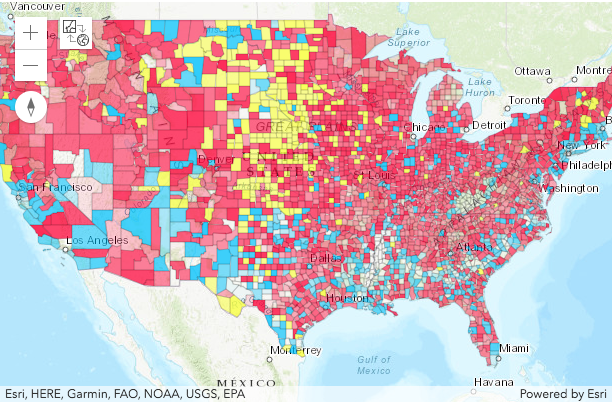">